<a href="https://colab.research.google.com/github/Deyv0R/repo1/blob/main/%D0%9B%D0%912_%D0%9A%D0%B8%D1%8F%D0%BD%D0%B8%D1%86%D1%8F_4_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

for t in tables:
    if any("Country" in str(col) for col in t.columns):
        df_raw = t
        break

df_raw.head()

/tmp/ipykernel_4300/2277027721.py:13: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [ ]:
print("Розмір датасета (рядки, стовпці):", df_raw.shape)

Розмір датасета (рядки, стовпці): (222, 4)


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df = df_raw.copy()

df.columns = ['Country', 'IMF', 'World_Bank', 'UN']

# видалення рядка 'World' та скидаємо індексацію
df = df[df['Country'].astype(str).str.strip() != 'World'].reset_index(drop=True)

df.head()

,Country,IMF,World_Bank,UN
0,United States,32383920,30769700,29298000
1,China[n 1],20851593,19498039,18743802
2,Germany,5452858,5050923,4659929
3,Japan,4379253,4435163,4026211
4,United Kingdom,4264794,4002588,3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.replace(['—', '-', '–', ''], np.nan, inplace=True)

numeric_cols = ['IMF', 'World_Bank', 'UN']
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Кількість пропусків у стовпцях:")
print(df.isna().sum())

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("\nПропуски після заміни:")
print(df.isna().sum())

Кількість пропусків у стовпцях:
Country        0
IMF           31
World_Bank    35
UN             9
dtype: int64

Пропуски після заміни:
Country       0
IMF           0
World_Bank    0
UN            0
dtype: int64


5. Ще раз вивести датасет

In [ ]:
df.head(10)

,Country,IMF,World_Bank,UN
0,United States,32383920.0,30769700.0,29298000.0
1,China[n 1],20851593.0,19498039.0,18743802.0
2,Germany,5452858.0,5050923.0,4659929.0
3,Japan,4379253.0,4435163.0,4026211.0
4,United Kingdom,4264794.0,4002588.0,3685881.0
5,India,4153191.0,3956067.0,3952244.0
6,France,3596094.0,3366316.0,3160443.0
7,Italy,2738164.0,2551557.0,2380825.0
8,Russia,2656452.0,2561310.0,2173386.0
9,Brazil,2635912.0,2279920.0,2185822.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
print("Кількість дублікатів до видалення:", df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("Кількість дублікатів після перевірки:", df.duplicated().sum())

Кількість дублікатів до видалення: 0
Кількість дублікатів після перевірки: 0


7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF,World_Bank,UN
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05
std,2.666759e+06,2.520399e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.895900e+04,1.992800e+04,8.840000e+03
50%,1.020420e+05,9.977400e+04,4.276500e+04
75%,6.614603e+05,6.260497e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['Diff_IMF_WB'] = (df['IMF'] - df['World_Bank']).abs()

top_diff = df.sort_values(by='Diff_IMF_WB', ascending=False)[['Country', 'IMF', 'World_Bank', 'Diff_IMF_WB']].head(5)
top_diff

,Country,IMF,World_Bank,Diff_IMF_WB
0,United States,3.238392e+07,3.076970e+07,1.614220e+06
1,China[n 1],2.085159e+07,1.949804e+07,1.353554e+06
196,Sint Maarten,6.614603e+05,1.888000e+03,6.595723e+05
145,Palestine[n 11][n 12],6.614603e+05,1.716700e+04,6.442933e+05
191,San Marino,2.417000e+03,6.260497e+05,6.236327e+05


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
corr_matrix = df[['IMF', 'World_Bank', 'UN']].corr()
corr_matrix

,IMF,World_Bank,UN
IMF,1.000000,0.998639,0.997343
World_Bank,0.998639,1.000000,0.997011
UN,0.997343,0.997011,1.000000


10. Обчислити середнє значення за стовпцями

In [ ]:
df[['IMF', 'World_Bank', 'UN']].mean()

,0
IMF,661460.289474
World_Bank,626049.693548
UN,522491.207547


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['Std_Dev'] = df[['IMF', 'World_Bank', 'UN']].std(axis=1)

highest_var = df.sort_values(by='Std_Dev', ascending=False)[['Country', 'Std_Dev']].head(1)
highest_var

,Country,Std_Dev
0,United States,1.543508e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
for col in ['IMF', 'World_Bank', 'UN']:
    max_c = df.loc[df[col].idxmax()]['Country']
    max_v = df[col].max()
    min_c = df.loc[df[col].idxmin()]['Country']
    min_v = df[col].min()
    print(f"[{col}] Найвищий: {max_c} ({max_v:,.0f} млн $), Найнижчий: {min_c} ({min_v:,.0f} млн $)")

[IMF] Найвищий: United States (32,383,920 млн $), Найнижчий: Tuvalu (65 млн $)
[World_Bank] Найвищий: United States (30,769,700 млн $), Найнижчий: Tuvalu (57 млн $)
[UN] Найвищий: United States (29,298,000 млн $), Найнижчий: Tuvalu (56 млн $)


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

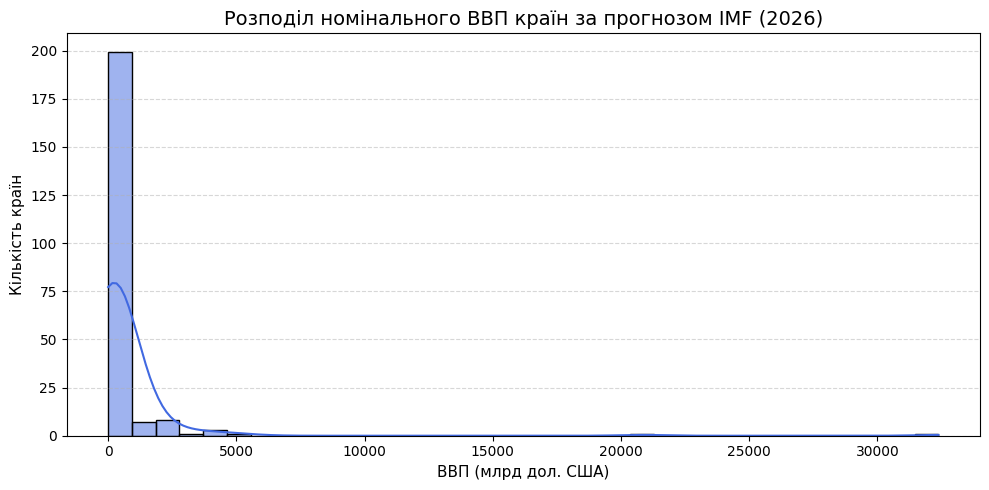

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['IMF'] / 1000, bins=35, kde=True, color='royalblue')

plt.title('Розподіл номінального ВВП країн за прогнозом IMF (2026)', fontsize=14)
plt.xlabel('ВВП (млрд дол. США)', fontsize=11)
plt.ylabel('Кількість країн', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Вигляд розподілу: Розподіл має яскраво виражену правобічну асиметрію. Переважна більшість країн світу зосереджена в діапазоні низьких та середніх значень ВВП (ближче до лівого краю графіка).

Країни, що виділяються: Так, є явні викиди-лідери праворуч, які формують довгий хвіст розподілу — це США та Китай, ВВП яких у рази перевищує показники всіх інших держав.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['Share_IMF'] = (df['IMF'] / df['IMF'].sum()) * 100
df['Share_WB'] = (df['World_Bank'] / df['World_Bank'].sum()) * 100
df['Share_UN'] = (df['UN'] / df['UN'].sum()) * 100

df[['Country', 'Share_IMF', 'Share_WB', 'Share_UN']].head(10)

,Country,Share_IMF,Share_WB,Share_UN
0,United States,22.153042,22.239355,25.372702
1,China[n 1],14.264061,14.092559,16.232538
2,Germany,3.730166,3.650646,4.035599
3,Japan,2.995739,3.205594,3.486786
4,United Kingdom,2.917441,2.892943,3.192053
5,India,2.841096,2.859319,3.422729
6,France,2.459999,2.433065,2.737012
7,Italy,1.873111,1.844184,2.061846
8,Russia,1.817213,1.851233,1.882199
9,Brazil,1.803162,1.647853,1.892969


Частки більшості країн залишаються відносно стабільними між різними оцінками, однак для країн із високою інфляцією, зміною курсів валют спостерігаються коливання.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

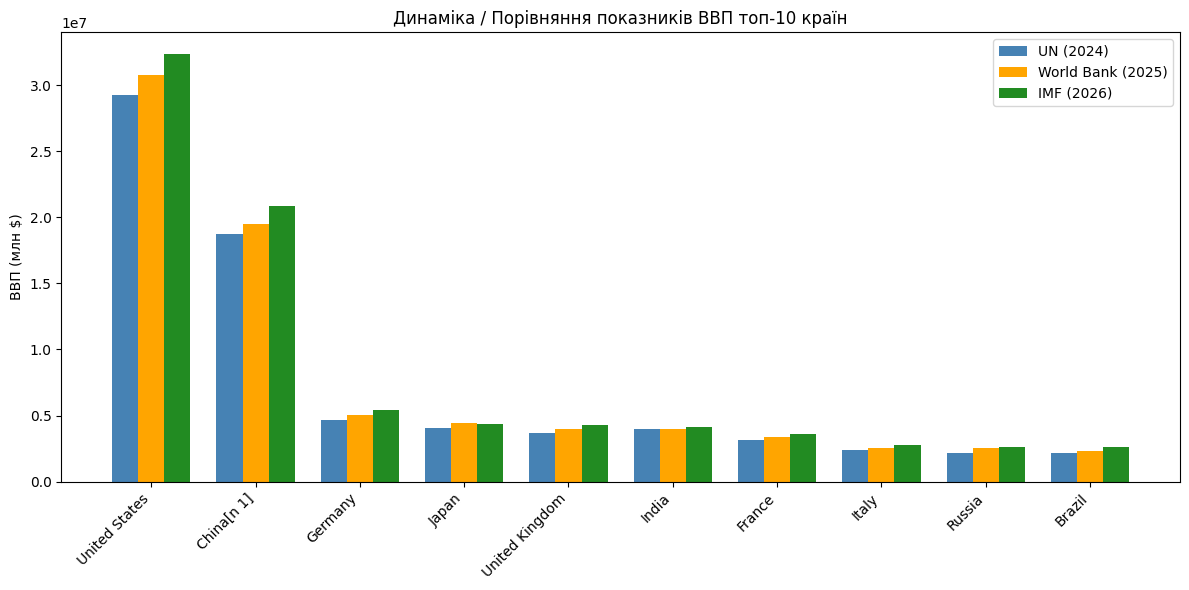

In [ ]:
top10 = df.sort_values(by='IMF', ascending=False).head(10)

plt.figure(figsize=(12, 6))
x = np.arange(len(top10))
width = 0.25

plt.bar(x - width, top10['UN'], width=width, label='UN (2024)', color='steelblue')
plt.bar(x, top10['World_Bank'], width=width, label='World Bank (2025)', color='orange')
plt.bar(x + width, top10['IMF'], width=width, label='IMF (2026)', color='forestgreen')

plt.xticks(x, top10['Country'], rotation=45, ha='right')
plt.ylabel('ВВП (млн $)')
plt.title('Динаміка / Порівняння показників ВВП топ-10 країн')
plt.legend()
plt.tight_layout()
plt.show()

Стабільне зростання показують: United States (США), China (Китай), India (Індія), Germany (Німеччина), United Kingdom (Велика Британія) та France (Франція). Їхні лінії на графіку послідовно підіймаються вгору від оцінки UN (2024) через World Bank (2025) до прогнозу IMF (2026).

Незначні коливання або спад спостерігаються у Japan (Японія) та окремих країн єврозони.